Project root: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt
Data dir: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw
Nodes: [11, 12, 13, 14, 15, 16]
FLAC files: 6
Resampling: audio and interpolated GPS -> 200ms
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_11_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_12_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_13_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_14_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_15_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Att

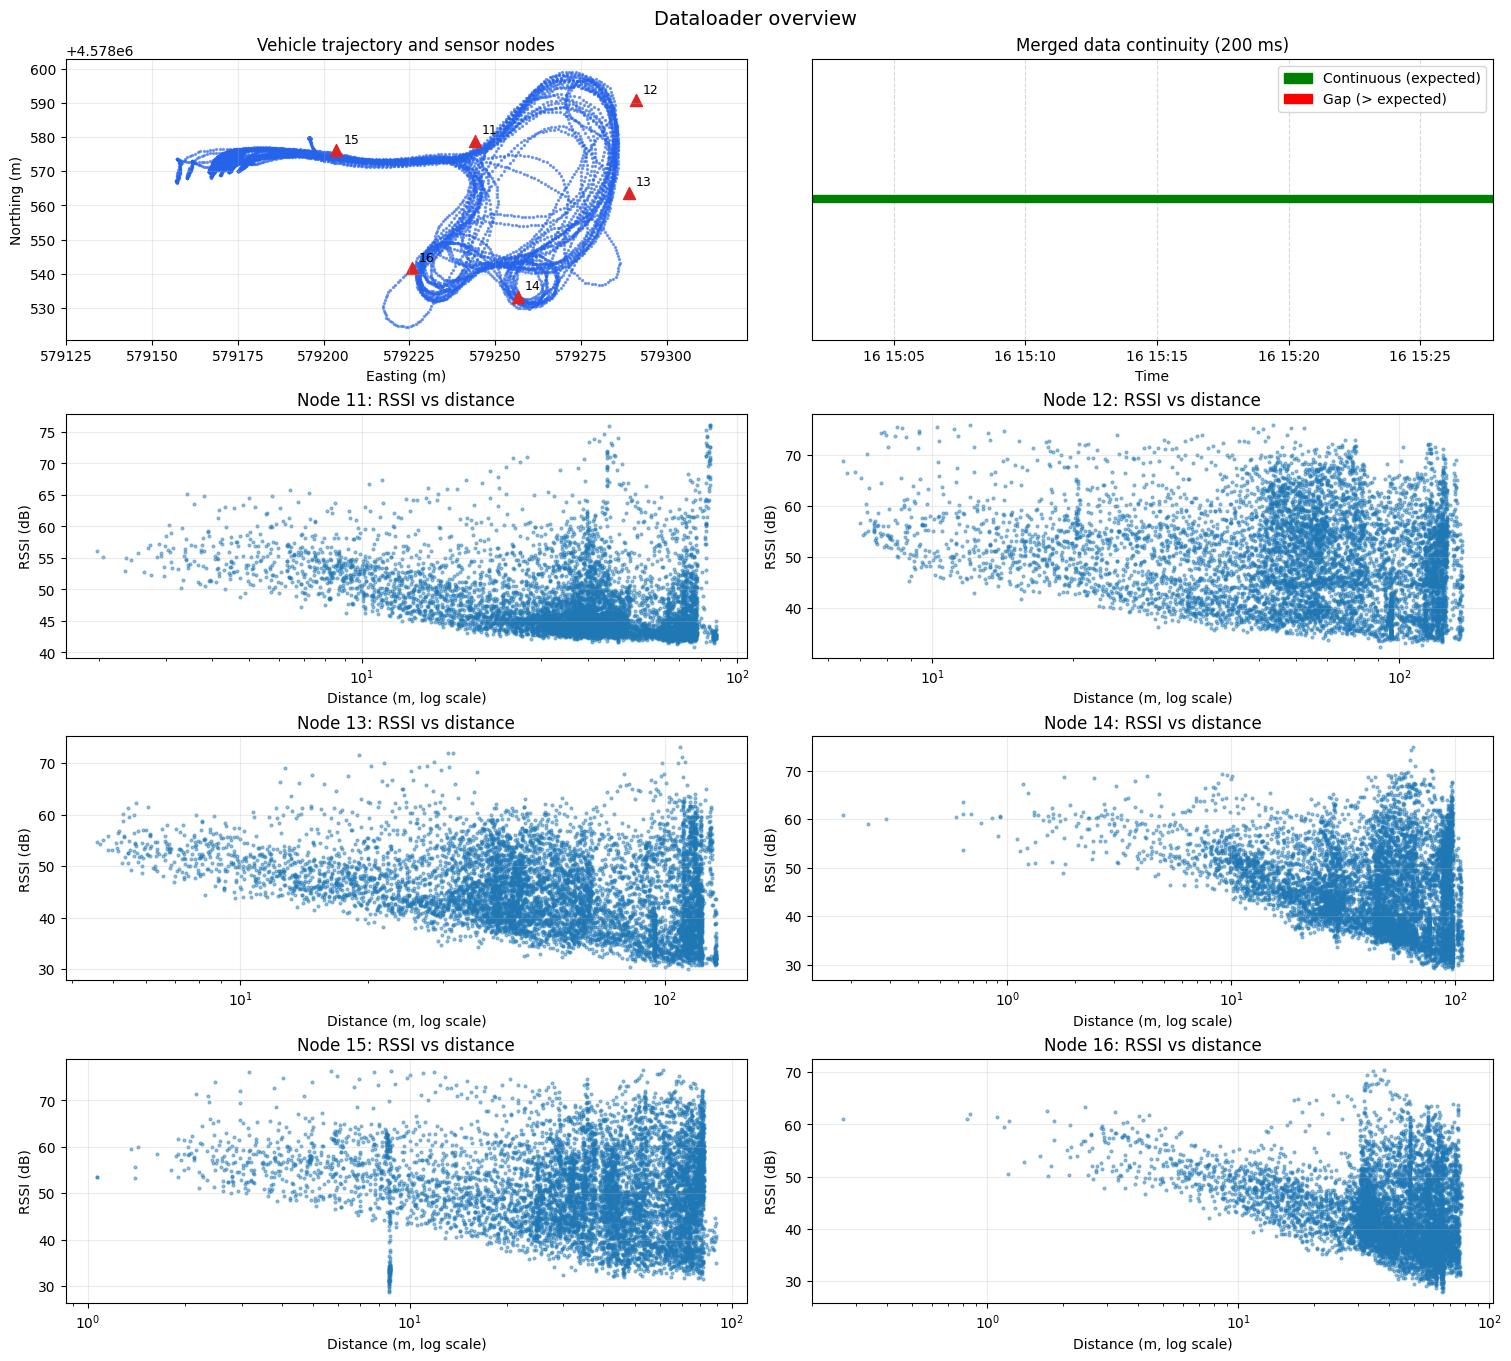

gdf_cleaned shape: (7766, 13)
normalized_cleaned shape: (7766, 14)
valid_indices: 7465


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import dataloader
importlib.reload(dataloader)

from dataloader import load_data, plot_gap_timeline

DATA_DIR = PROJECT_ROOT / "data" / "raw"
SENSOR_CSV = DATA_DIR / "wp_node_gps.csv"
GPS_CSV = DATA_DIR / "20260416_150152_gps2_gps.csv"

SAMPLE_MS = 200
RESAMPLE_RATE = f"{SAMPLE_MS}ms"
CHUNK_MS = 10

node_list = sorted(pd.read_csv(SENSOR_CSV)["Node #"].astype(int).tolist())
flac_files = sorted(DATA_DIR.glob("*_respeaker.flac"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Nodes: {node_list}")
print(f"FLAC files: {len(flac_files)}")
print(f"Resampling: audio and interpolated GPS -> {RESAMPLE_RATE}")

gdf_cleaned, normalized_cleaned, valid_indices, gdf_nodes = load_data(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    gps_csv=GPS_CSV,
    node_list=node_list,
    chunk_ms=CHUNK_MS,
    sample_ms=SAMPLE_MS,
    resample_rate=RESAMPLE_RATE,
    plot_gaps=False,
    interpolate_gps=True,
)


def plot_data_overview(gdf_cleaned, gdf_nodes, node_list, sample_ms=200):
    nodes = [
        node
        for node in node_list
        if f"rpi{node}" in gdf_cleaned.columns
        and f"distance_to_{node}" in gdf_cleaned.columns
    ]
    ncols = 2
    node_rows = max(1, int(np.ceil(len(nodes) / ncols)))

    fig = plt.figure(figsize=(15, 4.2 + 3.1 * node_rows), constrained_layout=True)
    gs = fig.add_gridspec(
        node_rows + 1,
        ncols,
        height_ratios=[1.15] + [1.0] * node_rows,
    )

    ax_path = fig.add_subplot(gs[0, 0])
    gdf_cleaned.plot(ax=ax_path, color="#2563eb", markersize=2, alpha=0.55)
    gdf_nodes.plot(ax=ax_path, color="#dc2626", marker="^", markersize=75)
    for _, row in gdf_nodes.iterrows():
        node_id = row.get("Node #", row.get("Node", ""))
        ax_path.annotate(
            str(node_id),
            (row.geometry.x, row.geometry.y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )
    ax_path.set_title("Vehicle trajectory and sensor nodes")
    ax_path.set_xlabel("Easting (m)")
    ax_path.set_ylabel("Northing (m)")
    ax_path.grid(True, alpha=0.25)
    ax_path.set_aspect("equal", adjustable="datalim")

    ax_gap = fig.add_subplot(gs[0, 1])
    plot_gap_timeline(
        gdf_cleaned,
        expected_freq_ms=sample_ms,
        title=f"Merged data continuity ({sample_ms} ms)",
        ax=ax_gap,
    )

    for idx, node in enumerate(nodes):
        ax = fig.add_subplot(gs[1 + idx // ncols, idx % ncols])
        rss_col = f"rpi{node}"
        dist_col = f"distance_to_{node}"
        sub = (
            gdf_cleaned[[rss_col, dist_col]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )
        sub = sub[sub[dist_col] > 0]

        ax.scatter(sub[dist_col], sub[rss_col], s=4, alpha=0.45)
        ax.set_xscale("log")
        ax.set_title(f"Node {node}: RSSI vs distance")
        ax.set_xlabel("Distance (m, log scale)")
        ax.set_ylabel("RSSI (dB)")
        ax.grid(True, alpha=0.25)

    for idx in range(len(nodes), node_rows * ncols):
        ax = fig.add_subplot(gs[1 + idx // ncols, idx % ncols])
        ax.axis("off")

    fig.suptitle("Dataloader overview", fontsize=14)
    return fig


fig = plot_data_overview(gdf_cleaned, gdf_nodes, node_list, sample_ms=SAMPLE_MS)
plt.show()

print(f"gdf_cleaned shape: {gdf_cleaned.shape}")
print(f"normalized_cleaned shape: {normalized_cleaned.shape}")
print(f"valid_indices: {len(valid_indices)}")


In [ ]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Audio-only feature loader. This cell intentionally does not read vehicle GPS.
# Sensor GPS is allowed as static metadata for node-aware models and plotting.
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_ROOT / "data" / "raw"
if "SENSOR_CSV" not in globals():
    SENSOR_CSV = DATA_DIR / "wp_node_gps.csv"
if "node_list" not in globals():
    node_list = sorted(pd.read_csv(SENSOR_CSV)["Node #"].astype(int).tolist())

import audio_feature_dataloader
importlib.reload(audio_feature_dataloader)

from audio_feature_dataloader import (
    build_audio_feature_dataset,
    plot_audio_feature_overview,
)

AUDIO_SAMPLE_MS = 200

audio_feature_df, audio_feature_long, audio_gdf_nodes = build_audio_feature_dataset(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    node_list=node_list,
    sample_ms=AUDIO_SAMPLE_MS,
    add_cross_sensor=True,
)

forbidden_tokens = ("latitude", "longitude", "distance_to", "vehicle", "geometry")
leak_cols = [
    col
    for col in audio_feature_df.columns
    if any(token in col.lower() for token in forbidden_tokens)
]
assert not leak_cols, f"Potential GPS/target leakage columns: {leak_cols[:10]}"

fig = plot_audio_feature_overview(
    feature_df=audio_feature_df,
    node_feature_df=audio_feature_long,
    gdf_nodes=audio_gdf_nodes,
    node_list=node_list,
    sample_ms=AUDIO_SAMPLE_MS,
)
plt.show()

print(f"audio_feature_df shape: {audio_feature_df.shape}")
print(f"audio_feature_long shape: {audio_feature_long.shape}")
print("No vehicle GPS, vehicle coordinates, or vehicle distance columns are present in audio_feature_df.")
print(audio_feature_df.head(3).to_string())


In [ ]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd

# Third stage: aggregate leakage-free feature artifacts and separate ground truth
# for a later two-tower model that ranks candidate sensor subsets.
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_ROOT / "data" / "raw"
if "SENSOR_CSV" not in globals():
    SENSOR_CSV = DATA_DIR / "wp_node_gps.csv"
if "GPS_CSV" not in globals():
    GPS_CSV = DATA_DIR / "20260416_150152_gps2_gps.csv"
if "node_list" not in globals():
    node_list = sorted(pd.read_csv(SENSOR_CSV)["Node #"].astype(int).tolist())

SAMPLE_MS = 200
RESAMPLE_RATE = f"{SAMPLE_MS}ms"
CHUNK_MS = 10
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

if "gdf_cleaned" not in globals() or "gdf_nodes" not in globals() or "valid_indices" not in globals():
    import dataloader
    importlib.reload(dataloader)
    from dataloader import load_data

    gdf_cleaned, normalized_cleaned, valid_indices, gdf_nodes = load_data(
        data_dir=DATA_DIR,
        sensor_csv=SENSOR_CSV,
        gps_csv=GPS_CSV,
        node_list=node_list,
        chunk_ms=CHUNK_MS,
        sample_ms=SAMPLE_MS,
        resample_rate=RESAMPLE_RATE,
        plot_gaps=False,
        interpolate_gps=True,
    )

if "audio_feature_long" not in globals():
    import audio_feature_dataloader
    importlib.reload(audio_feature_dataloader)
    from audio_feature_dataloader import build_audio_feature_dataset

    audio_feature_df, audio_feature_long, audio_gdf_nodes = build_audio_feature_dataset(
        data_dir=DATA_DIR,
        sensor_csv=SENSOR_CSV,
        node_list=node_list,
        sample_ms=SAMPLE_MS,
        add_cross_sensor=True,
    )

import processed_feature_builder
importlib.reload(processed_feature_builder)

from processed_feature_builder import (
    build_processed_two_tower_data,
    save_processed_two_tower_data,
)

processed_two_tower = build_processed_two_tower_data(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=node_list,
    audio_feature_long=audio_feature_long,
    history_steps=5,
    max_subset_size=3,
    utility_second_weight=0.45,
    utility_third_weight=0.20,
    softmax_temperature=4.0,
    verbose=True,
    progress_every=1000,
)

saved_paths = save_processed_two_tower_data(
    processed_two_tower,
    processed_dir=PROCESSED_DIR,
    prefix="vehicle_sensor_subset_200ms",
)

feature_leak_tokens = ("distance_to", "vehicle_x", "vehicle_y", "latitude", "longitude")
bad_feature_cols = [
    col
    for col in processed_two_tower["feature_wide_df"].columns
    if any(token in col.lower() for token in feature_leak_tokens)
]
assert not bad_feature_cols, f"Potential feature leakage columns: {bad_feature_cols[:10]}"

arrays = np.load(saved_paths["arrays_npz"])
print("Saved processed artifacts to:", PROCESSED_DIR)
print("context by time:", arrays["C_by_time"].shape)
print("action examples:", arrays["A_examples"].shape)
print("utility labels:", arrays["y_examples"].shape)
print("node features:", processed_two_tower["node_feature_df"].shape)
print("ground truth nodes:", processed_two_tower["ground_truth_node_df"].shape)
print("context_dim:", processed_two_tower["meta"]["context_dim"])
print("action_raw_dim:", processed_two_tower["meta"]["action_raw_dim"])

manifest = pd.DataFrame(
    [{"artifact": key, "path": str(path)} for key, path in saved_paths.items()]
)
display(manifest)
display(processed_two_tower["examples_df"].head())
